# 3. Editing State & Human Feedback

How to "pause" the LLM to request for human input (e.g stopping to get permission to perform a task, or prompting the user for additional feedback) then adding that to the state before continuing on in the graph

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
|  25/05/26  | Martin | CREATE   | Started Module 3. Streaming types | 

# Content

* [Streaming](#streaming)

# Streaming

Streaming is when the graph actively prints out its "thought-process". Here it is the graph state.

`.stream` and `.astream` are the sync and async versions for streaming results back.

Langgraph has 2 different modes for streaming:

- `values`: Streams the __full state__ of the graph after each node is called
- `updates`: Streams only the __updated__ to the graph after each node is called

In [1]:
import os
from dotenv import load_dotenv
from typing import Literal
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

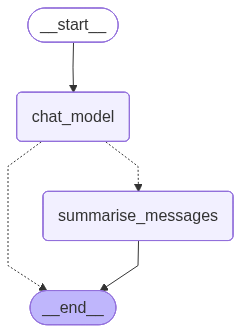

In [3]:
class State(MessagesState):
    summary: str

def chat_model(state: State):
    """
    Chat model that appends the summary before the user messages if it exists
    """
    summary = state.get("summary", "")
    if summary:
        summary_message = f"This is the current summary of the conversation: {summary}"

        # Add the summary message to the existing conversation
        messages = [SystemMessage(content=summary_message)] + state['messages']
    else:
        messages = state['messages']

    output = llm.invoke(messages)
    return {"messages": output}

def summarise_messages(state: State):
    """
    Creates or appends to the summary of the conversation before adding it to the state
    """
    summary = state.get("summary", "")
    if summary:
        new_summary = (
            f"The current summary of the conversation is {summary}"
            "Please extend the summary with the current message above:"
        )
    else:
        new_summary = "Create a summary based on the current messages above:"

    # Only creates the summary
    message_w_summary = state['messages'] + [HumanMessage(content=new_summary)]
    output = llm.invoke(message_w_summary)

    # Delete all but 2 of the most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {"summary": output.content, "messages": delete_messages}

def should_continue(state: State) -> Literal["summarise_messages", END]:
    """Return the next node to execute"""
    messages = state['messages']

    # Threshold here includes the AI messages
    if len(messages) > 6:
        return "summarise_messages"

    return END

# Define the graph
workflow = StateGraph(State)

workflow.add_node("chat_model", chat_model)
workflow.add_node("summarise_messages", summarise_messages)

workflow.add_edge(START, "chat_model")
workflow.add_conditional_edges("chat_model", should_continue)
workflow.add_edge("summarise_messages", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# Thread
config = {"configurable": {"thread_id": "1"}}

# Streaming mode = updates
for chunk in graph.stream(
    {"messages": [ HumanMessage(content="Hi I'm Martin") ]}, config, stream_mode='updates'
):
    print(chunk)
    print("===== Conversation =====")
    print(chunk['chat_model']['messages'].pretty_print())

{'chat_model': {'messages': AIMessage(content='It looks like we had a brief introduction earlier. How are you doing today, Martin?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 75, 'total_tokens': 94, 'completion_time': 0.041114881, 'completion_tokens_details': None, 'prompt_time': 0.264056212, 'prompt_tokens_details': None, 'queue_time': 0.051027407, 'total_time': 0.305171093}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5e4a-bf36-7040-a506-81c3d96c8ccc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 19, 'total_tokens': 94})}}
===== Conversation =====
================================== Ai Message ==================================

It looks like we had a brief introduction earlier. How are you doing today, Martin?
None


In [7]:
# Another thread
config = {"configurable": {"thread_id": "2"}}

# Streaming mode = updates
for event in graph.stream(
    {"messages": [ HumanMessage(content="Hi I'm Martin") ]}, config, stream_mode='values'
):
    for m in event['messages']:
        m.pretty_print()
    print('-'*25)

================================ Human Message =================================

Hi I'm Martin
-------------------------
================================ Human Message =================================

Hi I'm Martin
================================== Ai Message ==================================

Hi Martin, it's nice to meet you. Is there something I can help you with or would you like to chat?
-------------------------


In [ ]:
%load_ext watermark
%watermark